# 🤖💊 Prescription Medicine Recognition - DoseBotV2

**Goal:** Train a CNN to classify handwritten prescription medicine names (78 classes),
then deploy to HuggingFace Spaces.

**Dataset:** Doctor's Handwritten Prescription BD Dataset (Kaggle)

## Cell 1: Install Dependencies

In [1]:
!pip install tensorflow pandas numpy scikit-learn matplotlib seaborn opencv-python-headless Pillow

## Cell 2: Import Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

from PIL import Image
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.preprocessing.image import img_to_array, load_img, ImageDataGenerator
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

print("TensorFlow version:", tf.__version__)
print("GPUs Available:", len(tf.config.list_physical_devices('GPU')))

## Cell 2.5: Download & Extract Dataset

To download the dataset from Kaggle, you need to set up your Kaggle API credentials. The next code cell will create the `kaggle.json` file required for authentication.

**Important:** You need to replace `YOUR_KAGGLE_USERNAME` in the code with your actual Kaggle username. The Kaggle API key `KGAT_a8e88ad667cc7a7320dad58db1e079bf` has been pre-filled based on your input.

1.  Go to your Kaggle account page: `https://www.kaggle.com/<your-username>/account`
2.  Under the "API" section, you can find your Kaggle username. If you need a new API key, click "Create New API Token".
3.  Run the following cells after updating your username in `cell_54259d8f`.

In [4]:
# Install Kaggle library
!pip install kaggle

In [5]:
# Create .kaggle directory and create kaggle.json
import os
import json

kaggle_dir = os.path.expanduser('~/.kaggle')
if not os.path.exists(kaggle_dir):
    os.makedirs(kaggle_dir)

# Create kaggle.json with the provided API key
kaggle_json_path = os.path.join(kaggle_dir, 'kaggle.json')
kaggle_credentials = {
    "username": "chanupahansaja", # <<< IMPORTANT: REPLACE THIS WITH YOUR KAGGLE USERNAME
    "key": "KGAT_a8e88ad667cc7a7320dad58db1e079bf"
}

with open(kaggle_json_path, 'w') as f:
    json.dump(kaggle_credentials, f)

# Set appropriate permissions
!chmod 600 {kaggle_json_path}

print("Kaggle API key setup complete. Please remember to replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username in the code above if you haven't already.")

Kaggle API key setup complete. Please remember to replace 'YOUR_KAGGLE_USERNAME' with your actual Kaggle username in the code above if you haven't already.


In [6]:
# Download the dataset
# The dataset ID is 'mamun1113/doctors-handwritten-prescription-bd-dataset'
!kaggle datasets download mamun1113/doctors-handwritten-prescription-bd-dataset -p /content/data --unzip

# Verify the content of the data directory
print('Content of /content/data after download:')
!ls -la /content/data

Dataset URL: https://www.kaggle.com/datasets/mamun1113/doctors-handwritten-prescription-bd-dataset
License(s): ODbL-1.0
100% 19.1M/19.1M [00:00<00:00, 124MB/s] 

Content of /content/data after download:
total 12
drwxr-xr-x 3 root root 4096 Jun 20 18:02  .
drwxr-xr-x 1 root root 4096 Jun 20 18:02  ..
drwxr-xr-x 5 root root 4096 Jun 20 18:02 'Doctor’s Handwritten Prescription BD dataset'


## Cell 3: Configure Dataset Paths

In [ ]:
# Auto-discover the dataset folder name (handles special unicode apostrophe)
# In Colab, the Kaggle download (above) places data in /content/data, and
# os.getcwd() is /content -> DATA_DIR resolves correctly. Locally, start Jupyter
# from the notebook's folder or set NOTEBOOK_DIR to its absolute path.
NOTEBOOK_DIR = os.getcwd()
DATA_DIR = os.path.join(NOTEBOOK_DIR, "data")

print(f"Working directory: {NOTEBOOK_DIR}")
print(f"Data directory:    {DATA_DIR}")
print(f"Data dir exists:   {os.path.exists(DATA_DIR)}")

if not os.path.exists(DATA_DIR):
    raise FileNotFoundError(
        f"Data folder not found at {DATA_DIR}\n"
        f"Run the Kaggle download cell above (Colab), or start Jupyter from the "
        f"notebook folder / set NOTEBOOK_DIR to its absolute path."
    )

dataset_folder = os.listdir(DATA_DIR)[0]
BASE = os.path.join(DATA_DIR, dataset_folder)

TRAIN_IMG = os.path.join(BASE, "Training", "training_words")
TRAIN_CSV = os.path.join(BASE, "Training", "training_labels.csv")
TEST_IMG  = os.path.join(BASE, "Testing", "testing_words")
TEST_CSV  = os.path.join(BASE, "Testing", "testing_labels.csv")
VAL_IMG   = os.path.join(BASE, "Validation", "validation_words")
VAL_CSV   = os.path.join(BASE, "Validation", "validation_labels.csv")

# Handwritten words are wide rectangles, NOT squares. Using a square input
# (e.g. 128x128) warps the letters and destroys their morphology. We use a
# wide rectangular canvas and pad to preserve aspect ratio (see Cell 6).
IMG_W = 256   # width  (long edge - words are wide)
IMG_H = 64    # height (short edge)
NUM_CLASSES = 78
BATCH_SIZE = 32
EPOCHS = 60

print(f"Dataset: {dataset_folder}")
print(f"Input shape: {IMG_H}x{IMG_W} (HxW), aspect-ratio preserved with padding")
print(f"Train images: {len(os.listdir(TRAIN_IMG))}")
print(f"Test images:  {len(os.listdir(TEST_IMG))}")
print(f"Val images:   {len(os.listdir(VAL_IMG))}")

## Cell 4: Load & Explore Data

In [8]:
train_df = pd.read_csv(TRAIN_CSV)
test_df  = pd.read_csv(TEST_CSV)
val_df   = pd.read_csv(VAL_CSV)

print("Training data shape:", train_df.shape)
print("Columns:", train_df.columns.tolist())
print("\nSample rows:")
print(train_df.head(10))
print(f"\nUnique medicines: {train_df['MEDICINE_NAME'].nunique()}")
print(f"\nClass distribution:\n{train_df['MEDICINE_NAME'].value_counts()}")

Training data shape: (3120, 3)
Columns: ['IMAGE', 'MEDICINE_NAME', 'GENERIC_NAME']

Sample rows:
   IMAGE MEDICINE_NAME GENERIC_NAME
0  0.png         Aceta  Paracetamol
1  1.png         Aceta  Paracetamol
2  2.png         Aceta  Paracetamol
3  3.png         Aceta  Paracetamol
4  4.png         Aceta  Paracetamol
5  5.png         Aceta  Paracetamol
6  6.png         Aceta  Paracetamol
7  7.png         Aceta  Paracetamol
8  8.png         Aceta  Paracetamol
9  9.png         Aceta  Paracetamol

Unique medicines: 78

Class distribution:
MEDICINE_NAME
Aceta       40
Ace         40
Alatrol     40
Amodis      40
Atrizin     40
            ..
Telfast     40
Tridosil    40
Trilock     40
Vifas       40
Zithrin     40
Name: count, Length: 78, dtype: int64


## Cell 5: Visualize Sample Images

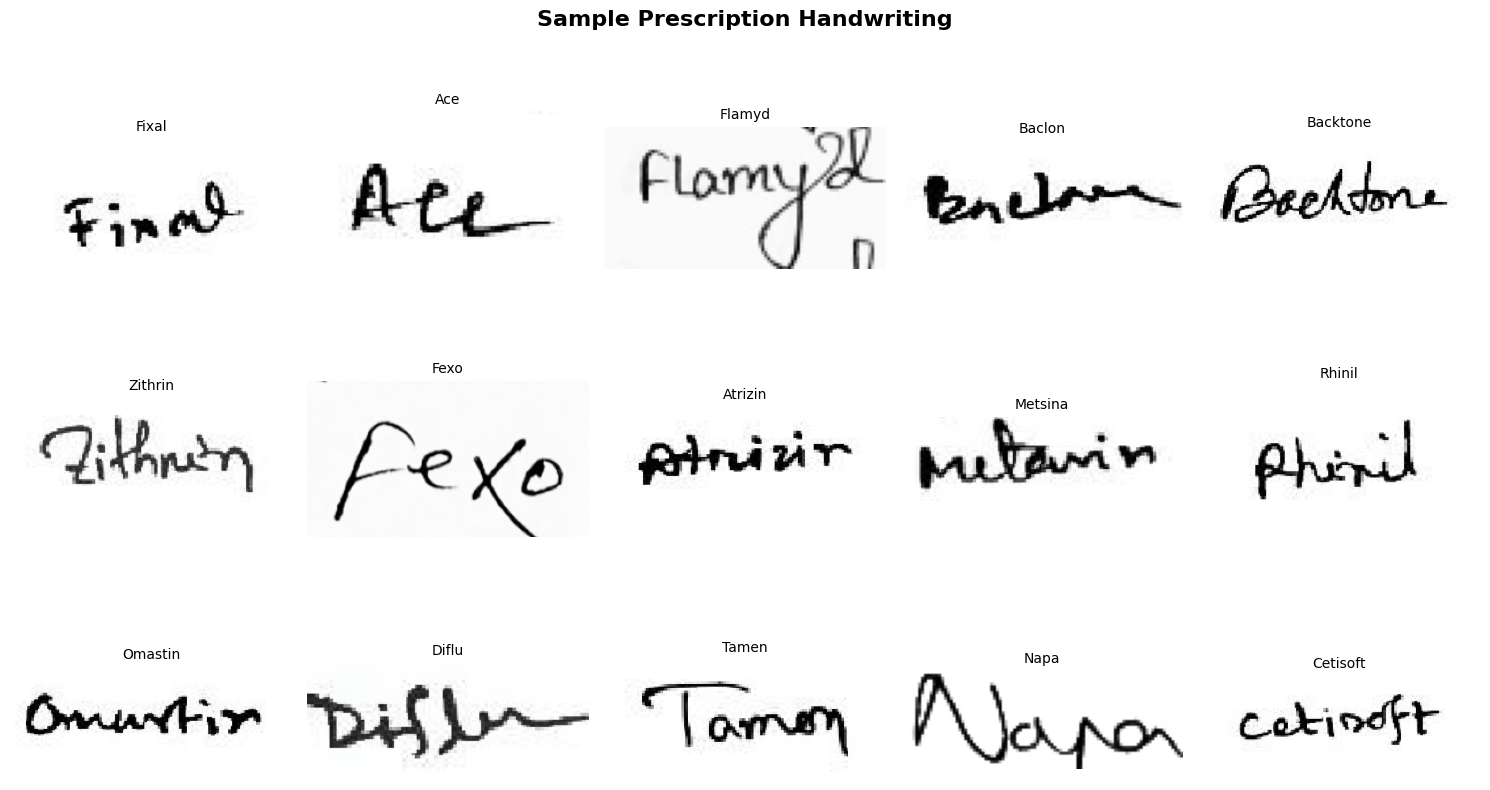

In [9]:
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle("Sample Prescription Handwriting", fontsize=16, fontweight='bold')

sample = train_df.groupby('MEDICINE_NAME').first().reset_index().sample(15, random_state=42)
for idx, (ax, (_, row)) in enumerate(zip(axes.flat, sample.iterrows())):
    img = cv2.imread(os.path.join(TRAIN_IMG, row['IMAGE']))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    ax.imshow(img)
    ax.set_title(row['MEDICINE_NAME'], fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_images.png", dpi=100)
plt.show()

## Cell 6: Data Loading Functions

In [ ]:
def resize_with_padding(img, target_w=IMG_W, target_h=IMG_H, pad_color=(255, 255, 255)):
    """Resize a PIL image to (target_w, target_h) WITHOUT distorting it.

    The image is scaled so its longest edge fits, then centered on a white
    canvas. This preserves the natural wide-and-short shape of handwritten
    words instead of squashing them into a square.
    """
    w, h = img.size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    img = img.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new("RGB", (target_w, target_h), pad_color)
    canvas.paste(img, ((target_w - new_w) // 2, (target_h - new_h) // 2))
    return canvas


def load_images_and_labels(img_folder, csv_path, target_w=IMG_W, target_h=IMG_H):
    """Load images and labels from folder + CSV (aspect-ratio preserved)."""
    df = pd.read_csv(csv_path)
    images, labels = [], []
    skipped = 0

    for _, row in df.iterrows():
        img_path = os.path.join(img_folder, row['IMAGE'])
        if not os.path.exists(img_path):
            skipped += 1
            continue
        img = Image.open(img_path).convert("RGB")
        img = resize_with_padding(img, target_w, target_h)
        images.append(np.array(img, dtype="float32"))
        labels.append(row['MEDICINE_NAME'])

    if skipped > 0:
        print(f"  Warning: skipped {skipped} missing images")

    images = np.array(images, dtype="float32") / 255.0  # shape: (N, IMG_H, IMG_W, 3)
    labels = np.array(labels)
    return images, labels

print("Loading training data...")
X_train, y_train_raw = load_images_and_labels(TRAIN_IMG, TRAIN_CSV)
print(f"  Shape: {X_train.shape}, Labels: {len(y_train_raw)}")

print("Loading validation data...")
X_val, y_val_raw = load_images_and_labels(VAL_IMG, VAL_CSV)
print(f"  Shape: {X_val.shape}, Labels: {len(y_val_raw)}")

print("Loading test data...")
X_test, y_test_raw = load_images_and_labels(TEST_IMG, TEST_CSV)
print(f"  Shape: {X_test.shape}, Labels: {len(y_test_raw)}")

## Cell 7: Encode Labels

In [11]:
# Fit label encoder on ALL labels combined to ensure consistency
all_labels = np.concatenate([y_train_raw, y_val_raw, y_test_raw])
label_encoder = LabelEncoder()
label_encoder.fit(all_labels)

y_train = to_categorical(label_encoder.transform(y_train_raw), NUM_CLASSES)
y_val   = to_categorical(label_encoder.transform(y_val_raw),   NUM_CLASSES)
y_test  = to_categorical(label_encoder.transform(y_test_raw),  NUM_CLASSES)

print(f"Classes ({len(label_encoder.classes_)}):")
print(list(label_encoder.classes_))

# Save label encoder for deployment
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

# Also save as JSON for easier use
label_map = {int(i): name for i, name in enumerate(label_encoder.classes_)}
with open("label_map.json", "w") as f:
    json.dump(label_map, f, indent=2)

print("\nLabel encoder saved!")

Classes (78):
[np.str_('Ace'), np.str_('Aceta'), np.str_('Alatrol'), np.str_('Amodis'), np.str_('Atrizin'), np.str_('Axodin'), np.str_('Az'), np.str_('Azithrocin'), np.str_('Azyth'), np.str_('Bacaid'), np.str_('Backtone'), np.str_('Baclofen'), np.str_('Baclon'), np.str_('Bacmax'), np.str_('Beklo'), np.str_('Bicozin'), np.str_('Canazole'), np.str_('Candinil'), np.str_('Cetisoft'), np.str_('Conaz'), np.str_('Dancel'), np.str_('Denixil'), np.str_('Diflu'), np.str_('Dinafex'), np.str_('Disopan'), np.str_('Esonix'), np.str_('Esoral'), np.str_('Etizin'), np.str_('Exium'), np.str_('Fenadin'), np.str_('Fexo'), np.str_('Fexofast'), np.str_('Filmet'), np.str_('Fixal'), np.str_('Flamyd'), np.str_('Flexibac'), np.str_('Flexilax'), np.str_('Flugal'), np.str_('Ketocon'), np.str_('Ketoral'), np.str_('Ketotab'), np.str_('Ketozol'), np.str_('Leptic'), np.str_('Lucan-R'), np.str_('Lumona'), np.str_('M-Kast'), np.str_('Maxima'), np.str_('Maxpro'), np.str_('Metro'), np.str_('Metsina'), np.str_('Monas'), n

## Cell 8: Data Augmentation

In [ ]:
# Mild augmentation only. Aggressive rotation/shear/brightness on top of heavy
# dropout was a major cause of underfitting (the model could never even fit the
# training data). Keep jitter small so letters stay legible.
datagen = ImageDataGenerator(
    rotation_range=5,
    zoom_range=0.05,
    width_shift_range=0.05,
    height_shift_range=0.05,
    fill_mode='nearest',
    cval=255  # pad with white to match resize_with_padding
)

datagen.fit(X_train)

# Visualize augmented samples
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Augmented Training Samples", fontsize=14)
sample_img = X_train[0:1]
for ax in axes.flat:
    aug_img = datagen.flow(sample_img, batch_size=1)[0][0]
    ax.imshow(np.clip(aug_img, 0, 1))
    ax.axis('off')
plt.tight_layout()
plt.savefig("augmented_samples.png", dpi=100)
plt.show()

## Cell 9: Build Improved CNN Model

In [ ]:
def build_model(input_shape=(IMG_H, IMG_W, 3), num_classes=NUM_CLASSES):
    """CNN feature extractor + light classifier.

    Regularization was drastically reduced vs. the original: the old model had
    Dropout(0.25) after EVERY conv block plus two Dropout(0.5) dense layers,
    which made it impossible to even fit the training set (<6% train acc). We
    now rely on BatchNorm + a single small dropout. Goal: let it overfit first,
    then add regularization back only if val/train gap becomes large.
    """
    model = Sequential([
        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 4
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),

        # Classifier (single dense layer, light dropout)
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),
        Dense(num_classes, activation='softmax')
    ])
    return model

model = build_model()
model.summary()

## Cell 10: Compile & Train

In [ ]:
# Lower LR (1e-3 -> 1e-4): the old rate caused the loss spikes / unstable
# accuracy and let the optimizer collapse onto the majority class.
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Class weights: counter imbalance so the model can't win by always guessing
# the majority class (the "always predicts Flexibac" failure mode).
y_train_int = label_encoder.transform(y_train_raw)
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(NUM_CLASSES),
    y=y_train_int
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights range: {class_weights.min():.2f} - {class_weights.max():.2f}")

callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=12, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint('best_model.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=BATCH_SIZE),
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight_dict,
    steps_per_epoch=len(X_train) // BATCH_SIZE
)

## Cell 11: Plot Training History

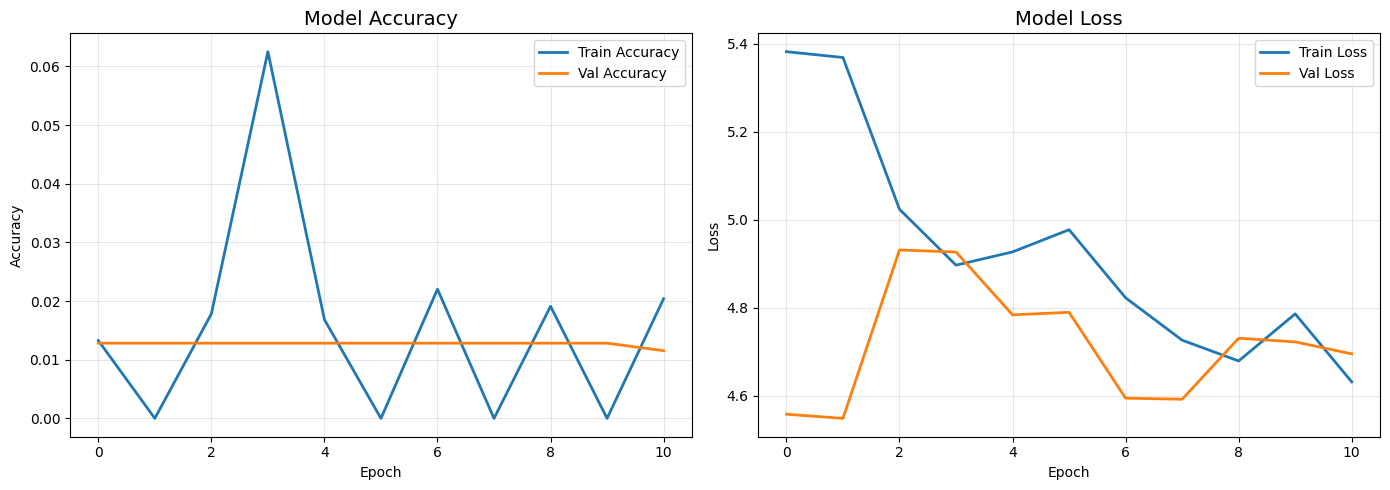

In [15]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2)
ax1.set_title('Model Accuracy', fontsize=14)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
ax2.set_title('Model Loss', fontsize=14)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=100)
plt.show()

## Cell 12: Evaluate on Test Set

In [16]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=1)
print(f"\n{'='*50}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")
print(f"{'='*50}")

# Classification report
predictions = model.predict(X_test)
pred_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(y_test, axis=1)

print("\nClassification Report:")
print(classification_report(true_classes, pred_classes,
                            target_names=label_encoder.classes_))

25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.0154 - loss: 4.5418

Test Accuracy: 1.54%
Test Loss: 4.5418
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step

Classification Report:
              precision    recall  f1-score   support

         Ace       0.00      0.00      0.00        10
       Aceta       0.00      0.00      0.00        10
     Alatrol       0.00      0.00      0.00        10
      Amodis       0.00      0.00      0.00        10
     Atrizin       0.00      0.00      0.00        10
      Axodin       0.00      0.00      0.00        10
          Az       0.00      0.00      0.00        10
  Azithrocin       0.00      0.00      0.00        10
       Azyth       0.04      0.30      0.07        10
      Bacaid       0.00      0.00      0.00        10
    Backtone       0.00      0.00      0.00        10
    Baclofen       0.00      0.00      0.00        10
      Baclon       0.00      0.00      0.00        10
      Bacmax       0.00      0.00      0.00        10
       Bekl

## Cell 13: Confusion Matrix

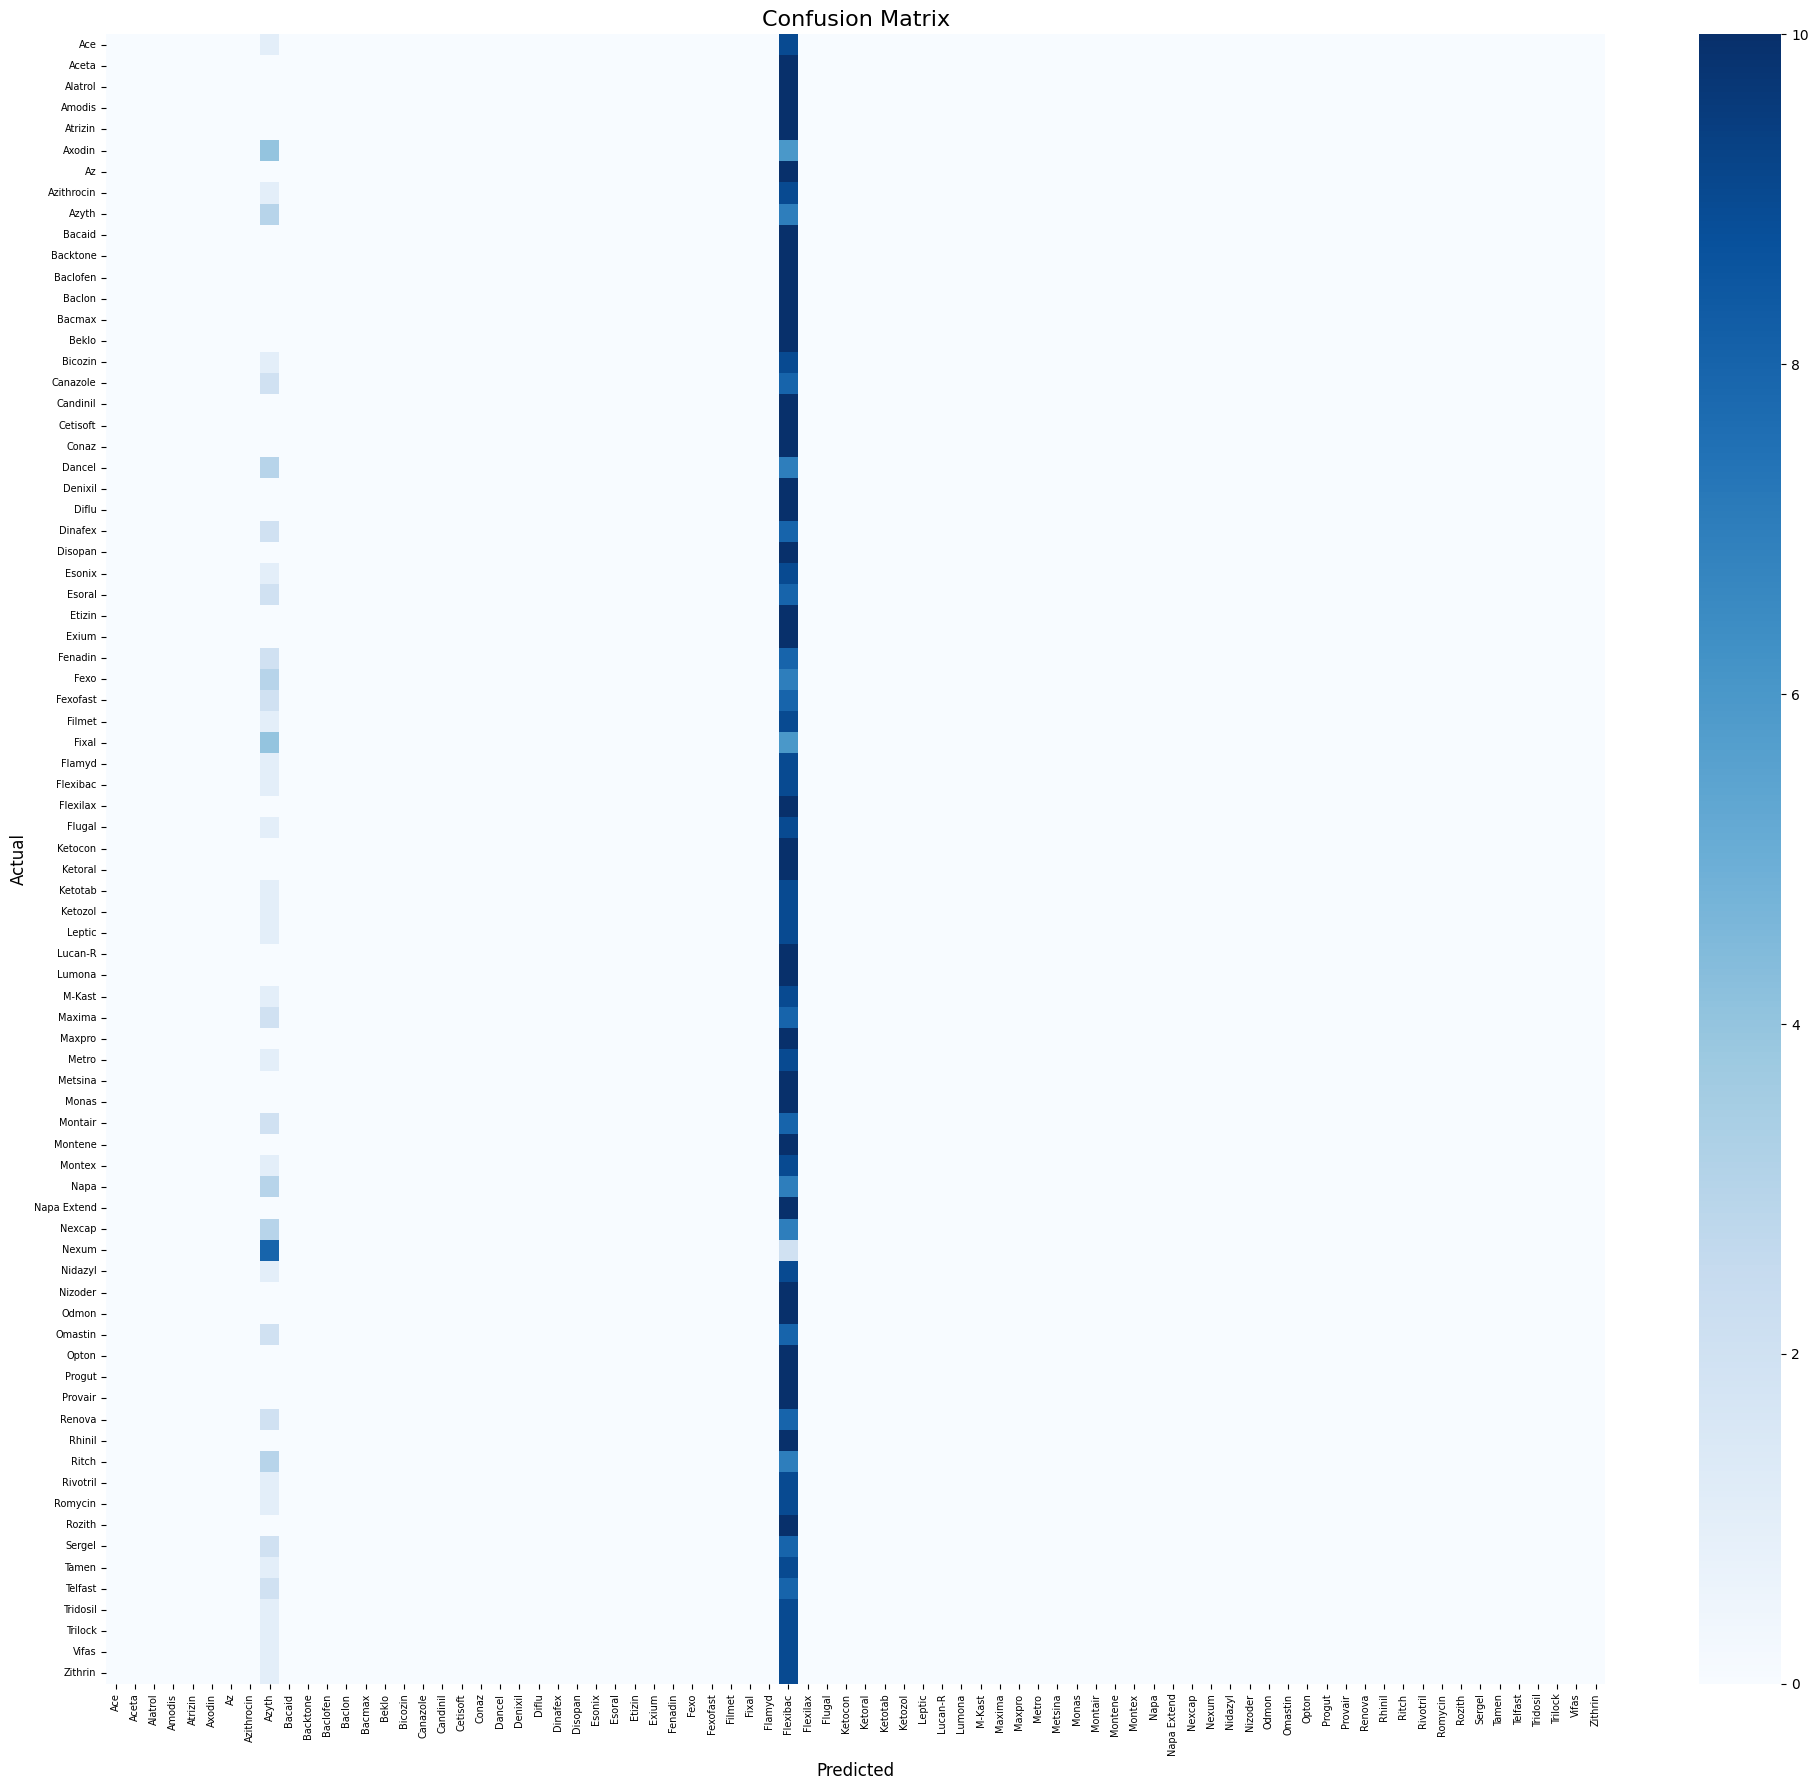

In [17]:
cm = confusion_matrix(true_classes, pred_classes)
plt.figure(figsize=(20, 18))
sns.heatmap(cm, annot=False, cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix', fontsize=16)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100)
plt.show()

## Cell 14: Test with Sample Predictions

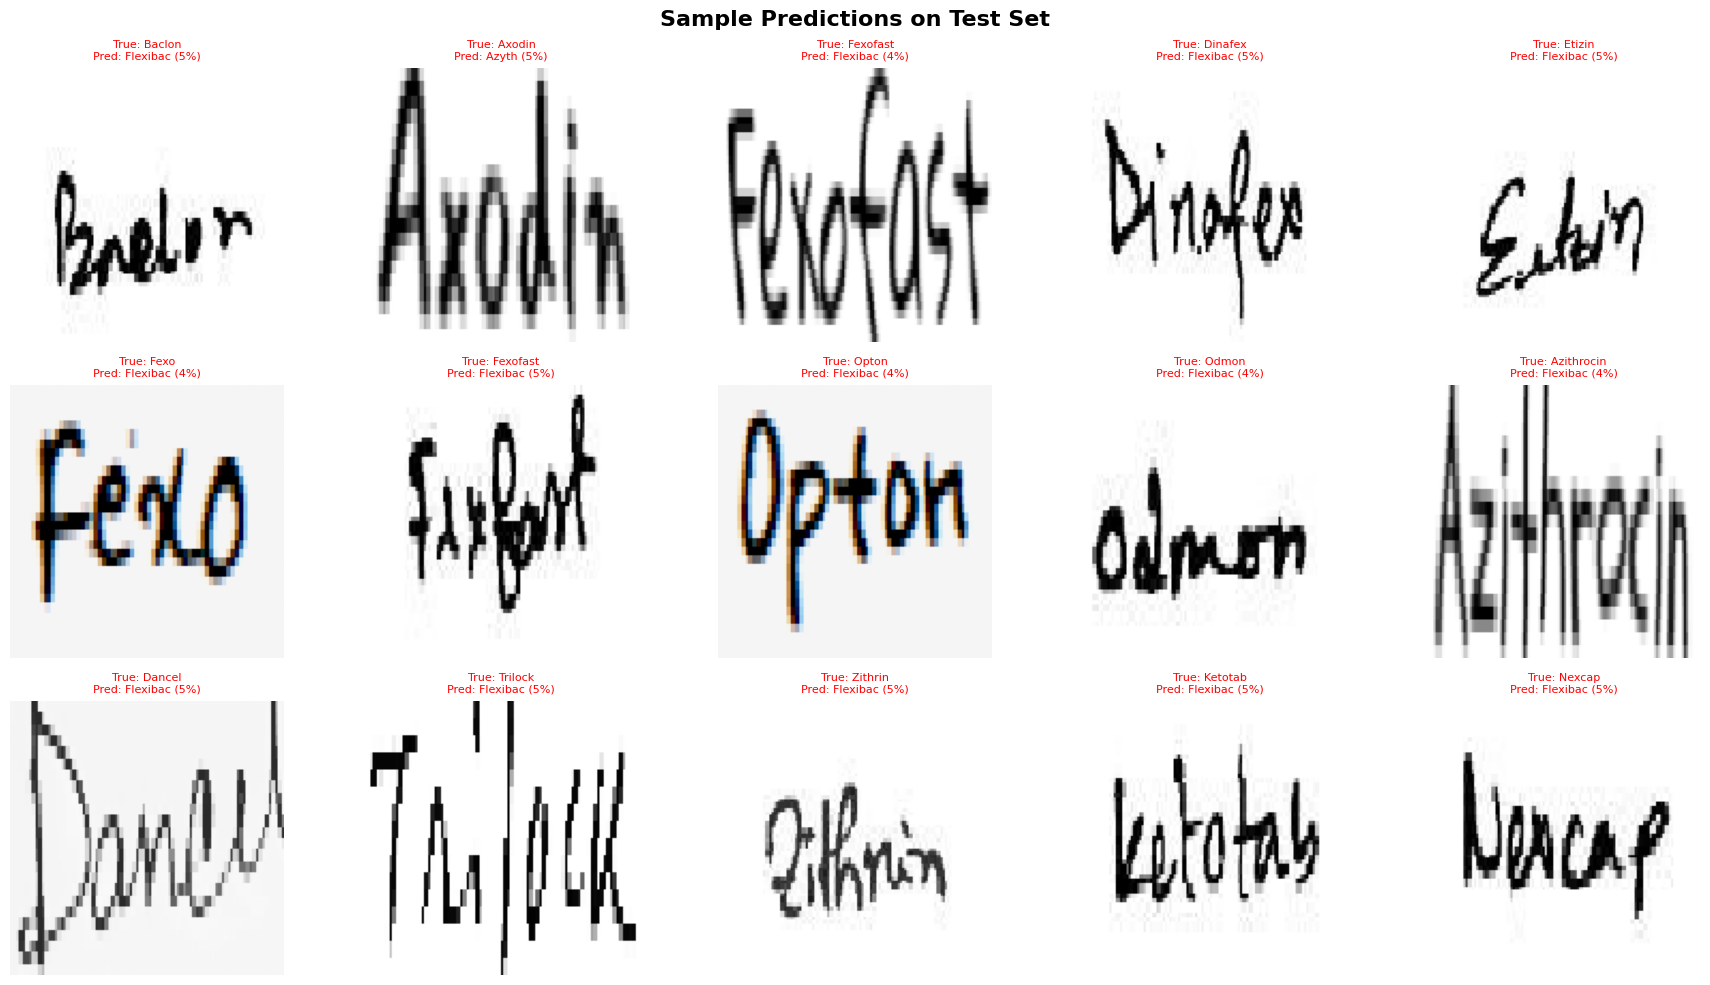

In [18]:
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
fig.suptitle("Sample Predictions on Test Set", fontsize=16, fontweight='bold')

indices = np.random.choice(len(X_test), 15, replace=False)
for ax, idx in zip(axes.flat, indices):
    img = X_test[idx]
    true_label = label_encoder.classes_[true_classes[idx]]
    pred_label = label_encoder.classes_[pred_classes[idx]]
    confidence = predictions[idx][pred_classes[idx]] * 100

    ax.imshow(img)
    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
                 fontsize=8, color=color)
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_predictions.png", dpi=100)
plt.show()

## Cell 15: Save Final Model for Deployment

In [ ]:
# Save in multiple formats
model.save("prescription_model.keras")
model.save("prescription_model.h5")

# Save model config
model_info = {
    "img_w": IMG_W,
    "img_h": IMG_H,
    "num_classes": NUM_CLASSES,
    "classes": list(label_encoder.classes_),
    "test_accuracy": float(test_accuracy),
    "test_loss": float(test_loss)
}
with open("model_info.json", "w") as f:
    json.dump(model_info, f, indent=2)

print("Models saved:")
print("  - prescription_model.keras")
print("  - prescription_model.h5")
print("  - label_encoder.pkl")
print("  - label_map.json")
print("  - model_info.json")
print(f"\nFinal Test Accuracy: {test_accuracy*100:.2f}%")

## Cell 16: Create HuggingFace Deployment Files

The following cells generate the files needed for deployment.

In [ ]:
# Generate app.py for HuggingFace Spaces
app_code = '''import gradio as gr
import tensorflow as tf
import numpy as np
import json
from PIL import Image

# Load model and label map
model = tf.keras.models.load_model("prescription_model.h5")

with open("label_map.json", "r") as f:
    label_map = json.load(f)

with open("model_info.json", "r") as f:
    model_info = json.load(f)

IMG_W = model_info["img_w"]
IMG_H = model_info["img_h"]


def resize_with_padding(img, target_w, target_h, pad_color=(255, 255, 255)):
    """Match the training preprocessing: scale to fit, then pad (no warping)."""
    w, h = img.size
    scale = min(target_w / w, target_h / h)
    new_w, new_h = max(1, int(round(w * scale))), max(1, int(round(h * scale)))
    img = img.resize((new_w, new_h), Image.BILINEAR)
    canvas = Image.new("RGB", (target_w, target_h), pad_color)
    canvas.paste(img, ((target_w - new_w) // 2, (target_h - new_h) // 2))
    return canvas


def predict_medicine(image):
    """Predict medicine name from handwritten prescription image."""
    if image is None:
        return {}, "Please upload an image"

    # Preprocess (aspect-ratio preserved, same as training)
    img = Image.fromarray(image).convert("RGB")
    img = resize_with_padding(img, IMG_W, IMG_H)
    img_array = np.array(img, dtype="float32") / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    predictions = model.predict(img_array, verbose=0)[0]
    top_k = 5
    top_indices = predictions.argsort()[-top_k:][::-1]

    results = {}
    details = []
    for i, idx in enumerate(top_indices):
        label = label_map[str(idx)]
        conf = float(predictions[idx])
        results[label] = conf
        details.append(f"{i+1}. {label}: {conf*100:.1f}%")

    top_medicine = label_map[str(top_indices[0])]
    top_conf = predictions[top_indices[0]] * 100
    summary = f"**Predicted Medicine:** {top_medicine} ({top_conf:.1f}% confidence)"

    return results, summary

# Build Gradio interface
with gr.Blocks(
    title="DoseBotV2 - Prescription Recognition",
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="cyan")
) as demo:
    gr.Markdown("""
    # 🤖💊 DoseBotV2 - Prescription Medicine Recognition
    Upload a handwritten prescription image to identify the medicine name.
    Trained on 78 medicine classes from the Doctor\\'s Handwritten Prescription BD Dataset.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(label="Upload Prescription Image", type="numpy")
            predict_btn = gr.Button("🔍 Identify Medicine", variant="primary", size="lg")
            gr.Examples(
                examples=[],
                inputs=image_input,
                label="Try these examples"
            )

        with gr.Column(scale=1):
            label_output = gr.Label(label="Prediction Confidence", num_top_classes=5)
            text_output = gr.Markdown(label="Result")

    predict_btn.click(
        fn=predict_medicine,
        inputs=image_input,
        outputs=[label_output, text_output]
    )

    gr.Markdown(f"""
    ---
    **Model Info:** CNN trained on {model_info['num_classes']} medicine classes |
    Test Accuracy: {model_info['test_accuracy']*100:.1f}%
    """)

demo.launch()
'''

with open("app.py", "w") as f:
    f.write(app_code)
print("Created: app.py")

# Generate requirements.txt
req = """tensorflow-cpu==2.16.1
gradio>=4.0.0
numpy
Pillow
"""
with open("requirements.txt", "w") as f:
    f.write(req)
print("Created: requirements.txt")

# Generate README.md for HF Space
readme = """---
title: DoseBotV2
emoji: 💊
colorFrom: blue
colorTo: cyan
sdk: gradio
sdk_version: 5.34.2
app_file: app.py
pinned: false
license: mit
---

# 🤖💊 DoseBotV2 - Prescription Medicine Recognition

Upload a handwritten prescription image to identify the medicine name.

## Model
- **Architecture:** CNN (4 conv blocks + BatchNorm + GlobalAvgPooling)
- **Input:** 256x64 RGB images (aspect-ratio preserved with padding)
- **Classes:** 78 medicine names
- **Dataset:** Doctor's Handwritten Prescription BD Dataset
"""
with open("README_HF.md", "w") as f:
    f.write(readme)
print("Created: README_HF.md")
print("\n✅ All deployment files generated!")

## Cell 17: Upload to HuggingFace (Run Manually)

```bash
# Install huggingface_hub
pip install huggingface_hub

# Login
huggingface-cli login

# Clone your space
git clone https://huggingface.co/spaces/Chanu2003/DoseBotV2
cd DoseBotV2

# Copy these files into the cloned repo:
#   - app.py
#   - requirements.txt
#   - README_HF.md -> rename to README.md
#   - prescription_model.h5
#   - label_map.json
#   - model_info.json

# Push to HuggingFace
git add .
git commit -m "Deploy DoseBotV2 prescription recognition model"
git push
```